In [15]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


Una corrección relativista para el problema de dos cuerpos de Kepler, sistema Sol-planeta, puede describirse en coordenadas polares con la ecuación:

$$
\ddot{u}(\theta) + u(\theta) - \frac{1}{\alpha} - \delta u^2(\theta) = 0
$$

Donde $u(\theta) = 1/r(\theta)$, el Sol se encuentra en el origen, $\alpha$ y $\delta$ son constantes. El término con $\delta$ es la corrección relativista.

1. Formular el problema como un sistema de orden uno de la forma $\dot{y} = f(\theta, y)$. Observar que la variable independiente no es el tiempo sino ángulos en polares.

2. Resolver el problema de Kepler $(\delta = 0)$, con condiciones iniciales $r(0) = \alpha/(1+\epsilon)$ y $\dot{r}(0) = 0$. $\epsilon$ es la excentricidad de la órbita: $0 \leq \epsilon < 1$ para órbitas cerradas, $\epsilon \geq 1$ para órbitas abiertas. La condición $\dot{r}(0) = 0$ (velocidad radial cero) significa que medimos los ángulos a partir del perihelio (punto más cercano al Sol).

Graficar soluciones con $\alpha = 1$ para distintos valores de $\epsilon$. Observar qué pasa cuando $\theta > 2\pi$ (3 o 4 vueltas).

In [16]:
def sistema(estado, alpha, delta):
    u, v = estado

    dU_dtheta = v
    dV_dtheta = -u + 1/alpha + delta * u**2

    return np.array([dU_dtheta, dV_dtheta])

In [17]:
def euler(u0, v0, alpha, delta, theta0, thetaf, h):
    num_pasos = int((thetaf - theta0) / h)

    theta = np.linspace(theta0, thetaf, num_pasos + 1)

    U = np.zeros(num_pasos + 1)
    V = np.zeros(num_pasos + 1)

    U[0] = u0
    V[0] = v0

    for i in range(num_pasos):
        estado = np.array([U[i], V[i]])
        pendiente = sistema(estado, alpha, delta)

        U[i+1] = U[i] + h * pendiente[0]
        V[i+1] = V[i] + h * pendiente[1]

    return theta, U, V

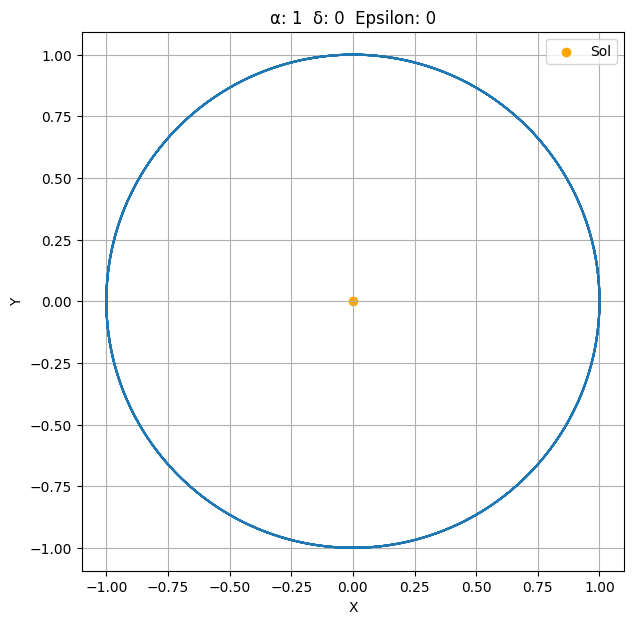

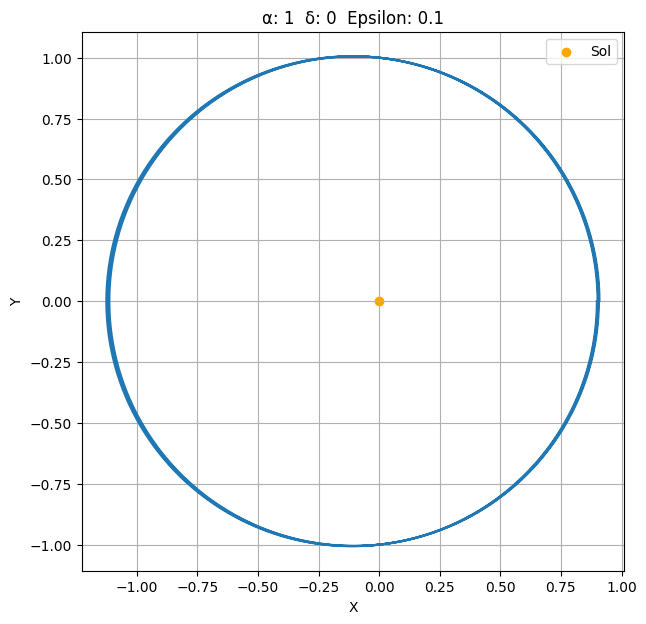

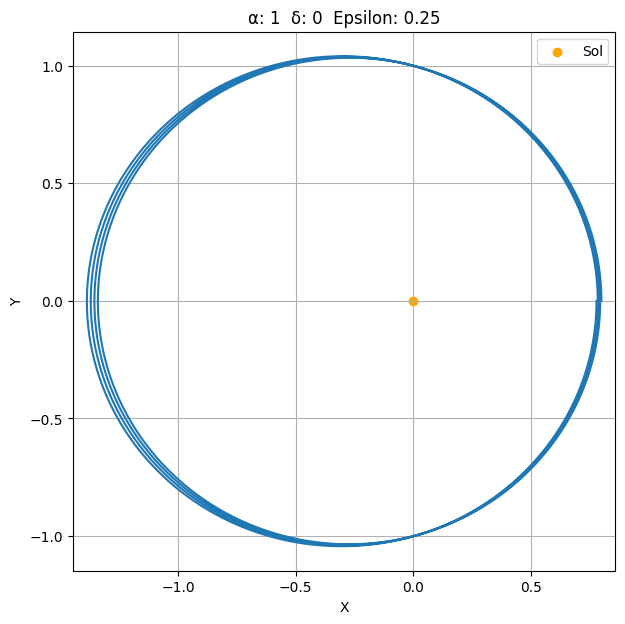

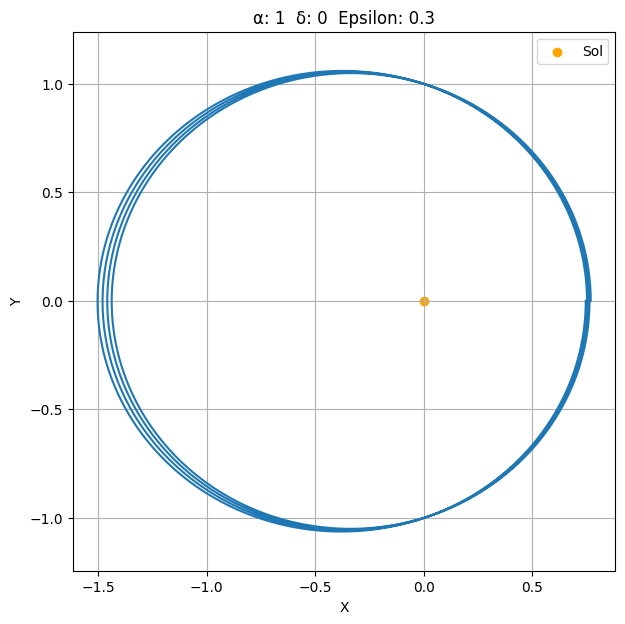

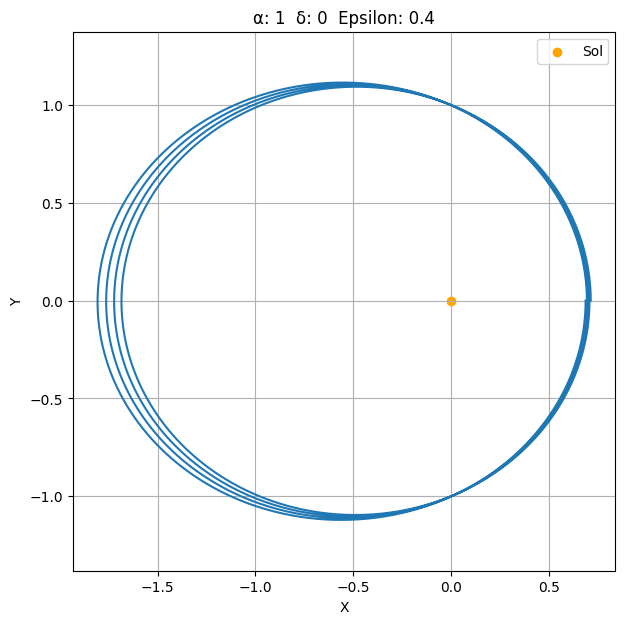

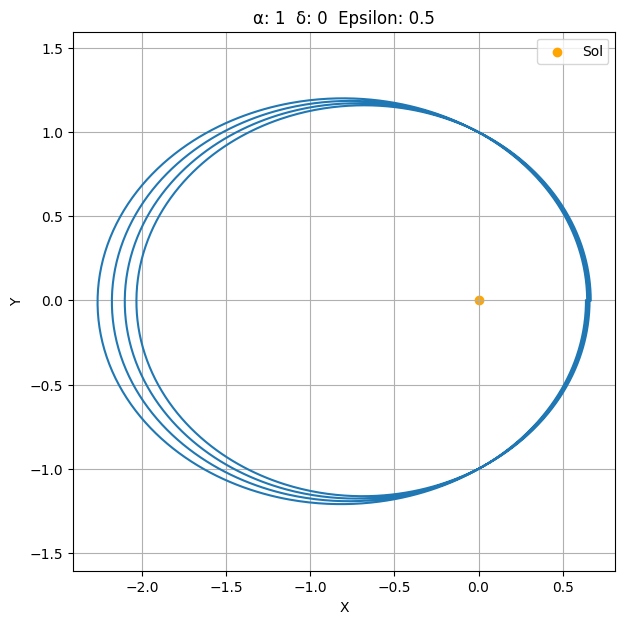

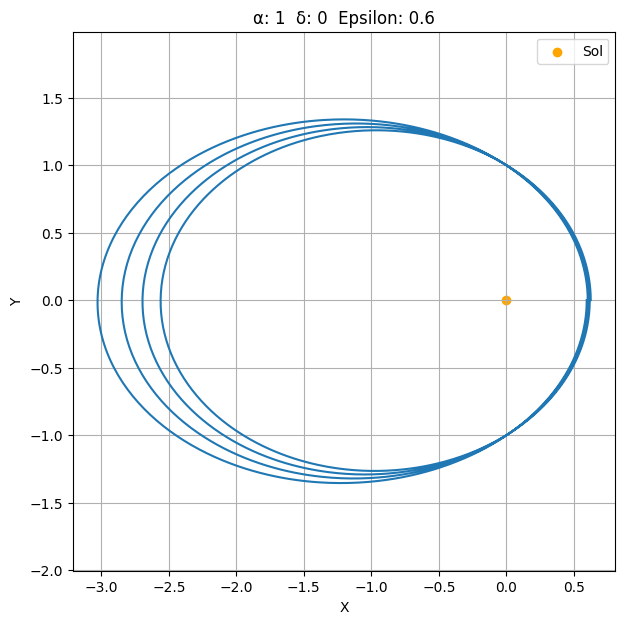

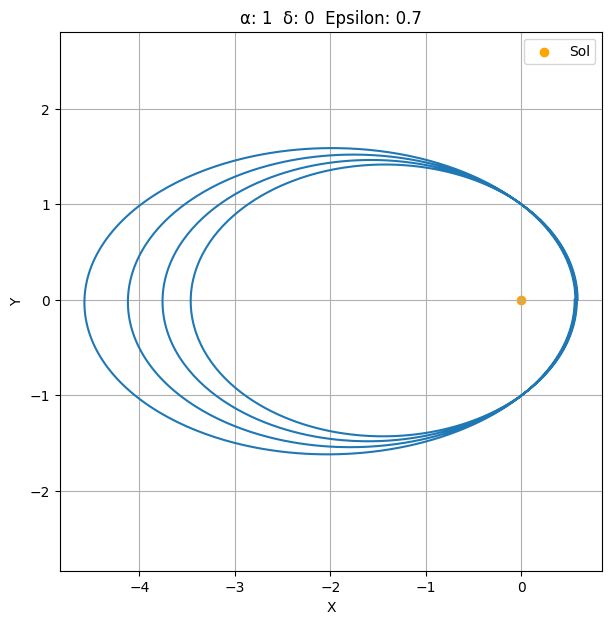

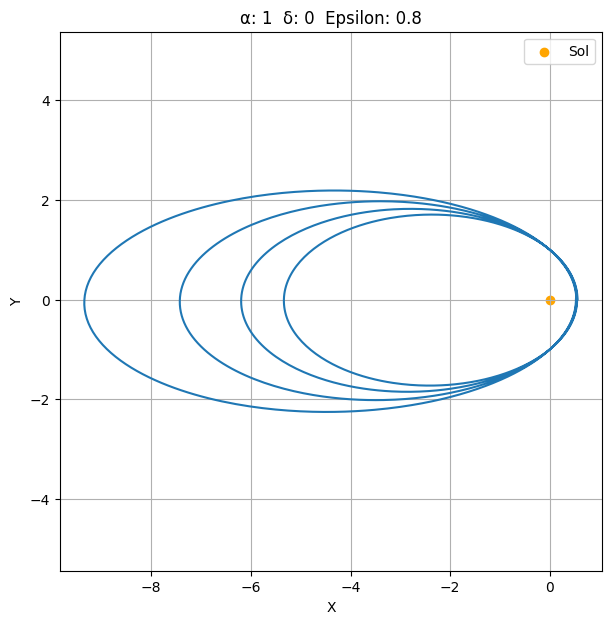

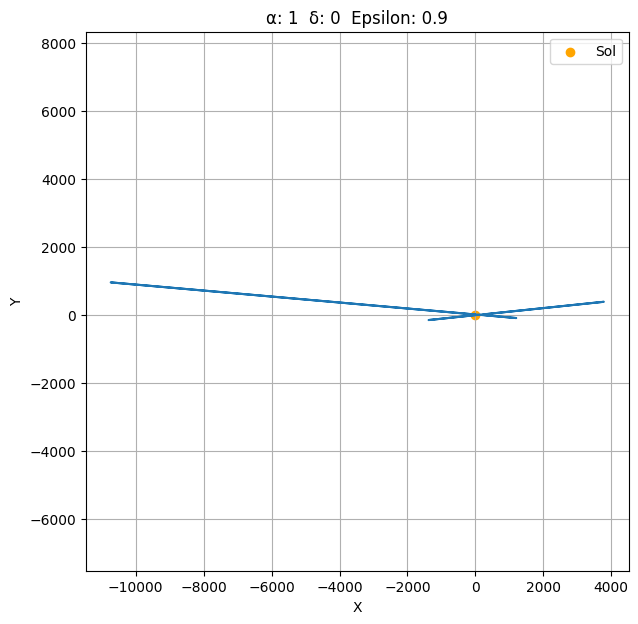

In [18]:
# Parámetros

delta = 0
alpha = 1

theta0 = 0
thetaf = 8 * np.pi
h = 0.01

epsilon = [0, 0.1, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for ep in epsilon:

    # r(0) = alpha / (1 + epsilon)
    r0 = alpha / (1 + ep)

    # u = 1/r
    u0 = 1 / r0
    v0 = 0

    theta, U, V = euler(u0, v0, alpha, delta, theta0, thetaf, h)

    R = 1 / U

    X = R * np.cos(theta)
    Y = R * np.sin(theta)

    plt.figure(figsize=(7, 7))
    plt.plot(X, Y)
    plt.scatter(0, 0, color="orange", label="Sol")
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'α: {alpha}  δ: {delta}  Epsilon: {ep}')
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()

3. Resolver el problema relativista para $\delta = 0.05$ en las mismas condiciones iniciales del ítem anterior y comparar.

El efecto se conoce como precesión del perihelio y las mediciones sobre la órbita de Mercurio fueron utilizadas por Albert Einstein como evidencia experimental de la Teoría General de la Relatividad.

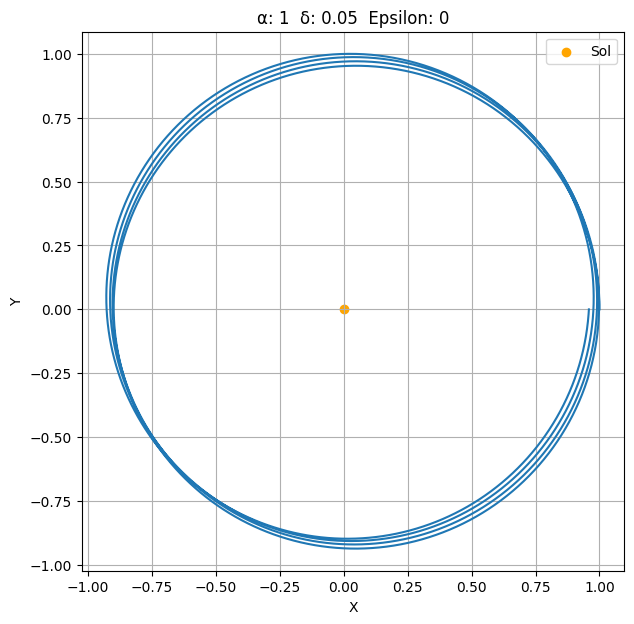

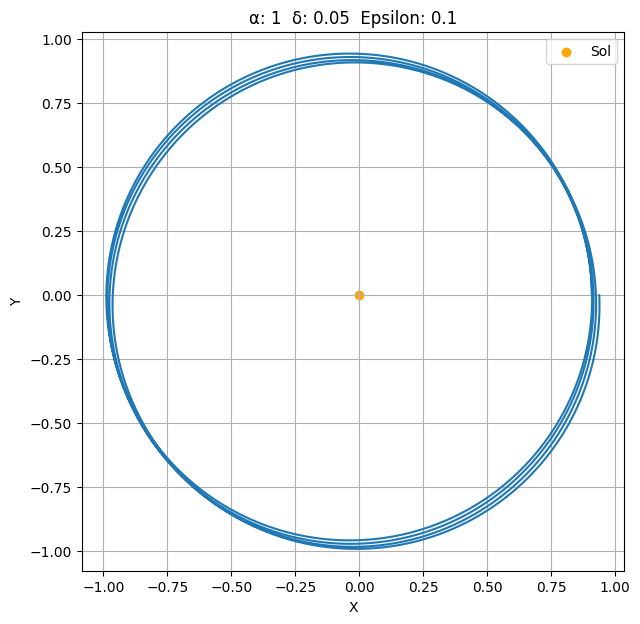

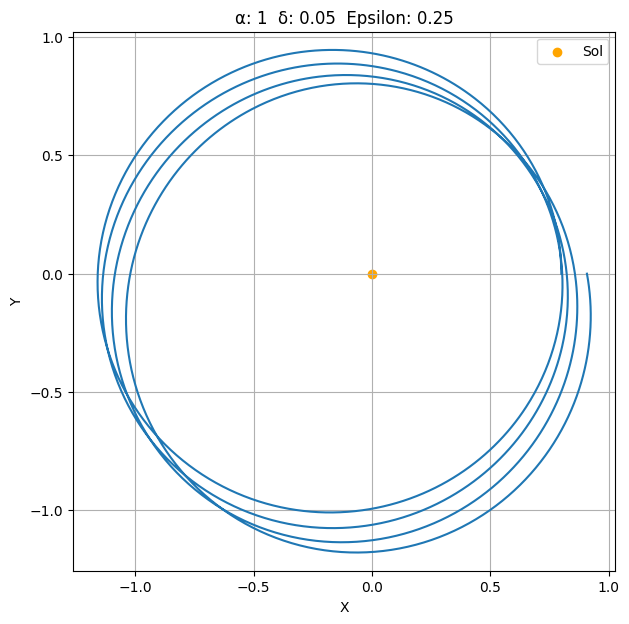

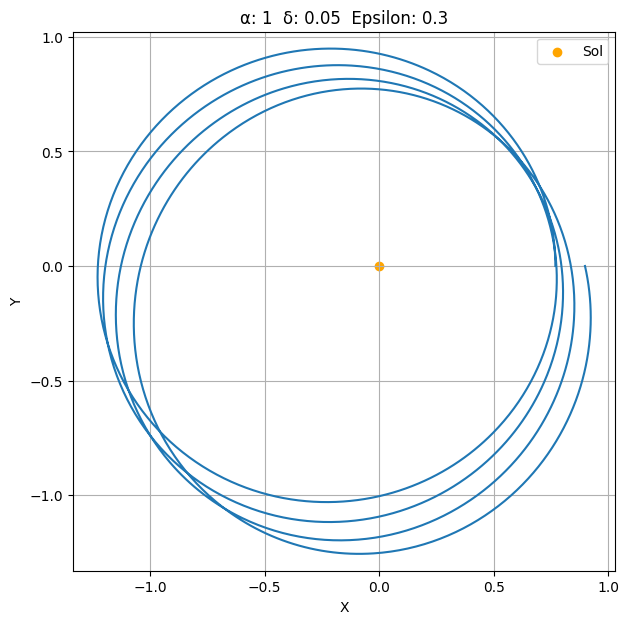

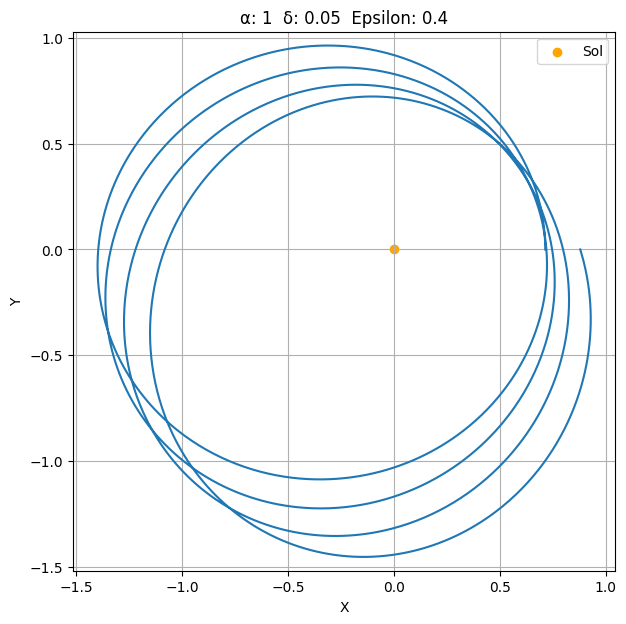

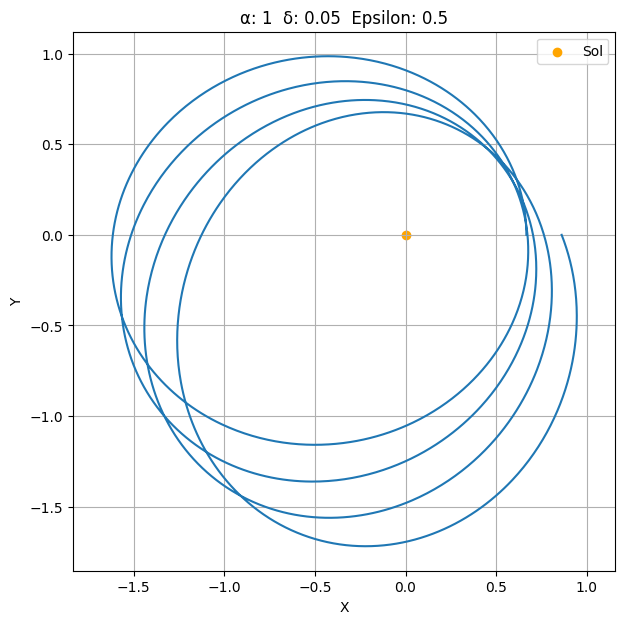

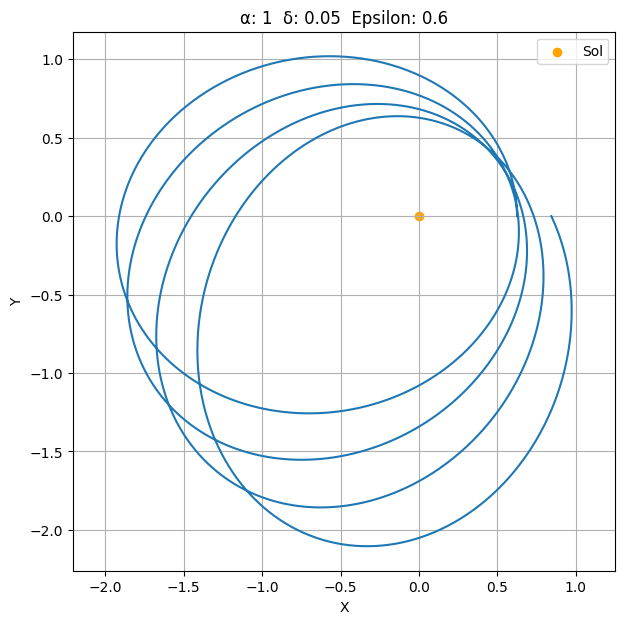

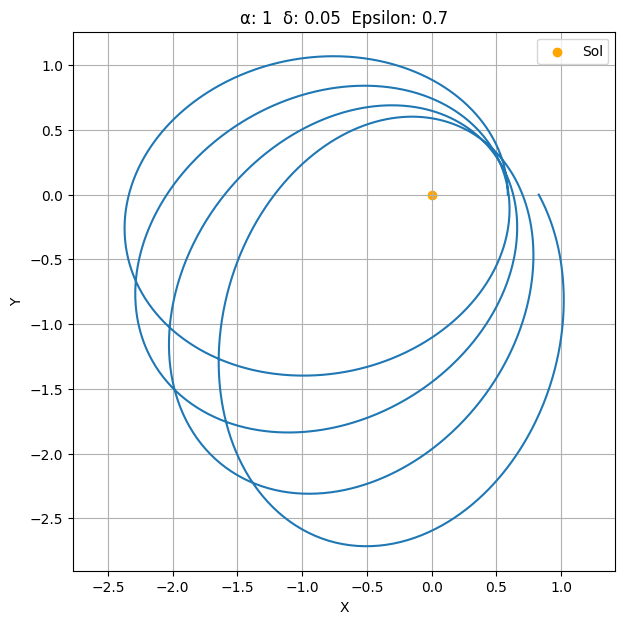

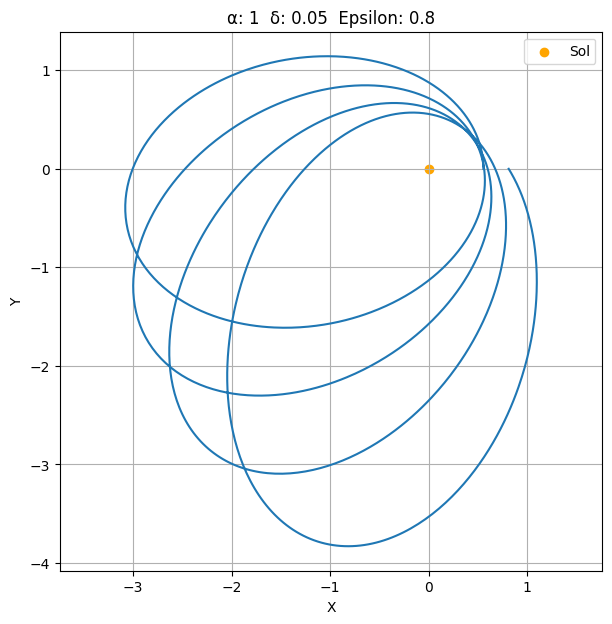

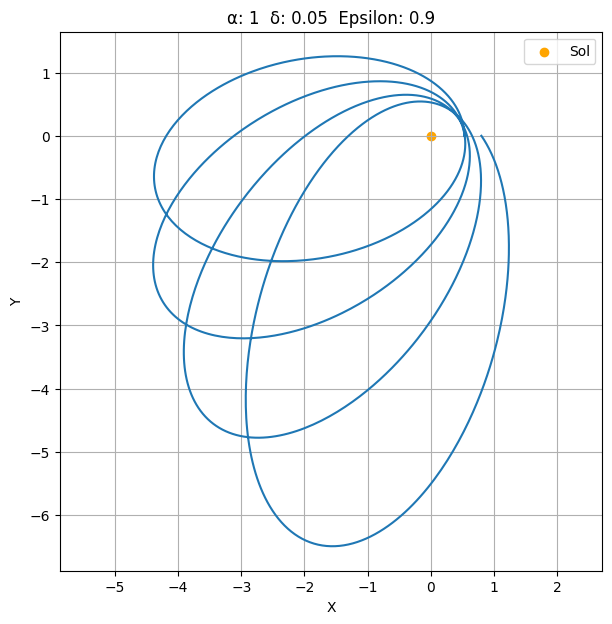

In [20]:
# Parámetros

delta = 0.05
alpha = 1

theta0 = 0
thetaf = 8 * np.pi
h = 0.01

epsilon = [0, 0.1, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for ep in epsilon:

    # r(0) = alpha / (1 + epsilon)
    r0 = alpha / (1 + ep)

    # u = 1/r
    u0 = 1 / r0
    v0 = 0

    theta, U, V = euler(u0, v0, alpha, delta, theta0, thetaf, h)

    R = 1 / U

    X = R * np.cos(theta)
    Y = R * np.sin(theta)

    plt.figure(figsize=(7, 7))
    plt.plot(X, Y)
    plt.scatter(0, 0, color="orange", label="Sol")
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'α: {alpha}  δ: {delta}  Epsilon: {ep}')
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()